In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md




In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv(f'D:\work\NTI ML\Final Project\AB_NYC_2019.csv')
data.head(15)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 7-8: malformed \N character escape (591594839.py, line 1)

# New Section

In [ ]:
print("Shape:", data.shape)

Shape: (48895, 16)


In [ ]:
data = data.drop(columns=[
    "id",
    "host_id",
    "host_name",
    "last_review",
    "name"
])

In [ ]:
data.dtypes

,0
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64
minimum_nights,int64
number_of_reviews,int64
reviews_per_month,float64
calculated_host_listings_count,int64


In [ ]:
data['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

<Axes: xlabel='neighbourhood_group', ylabel='count'>

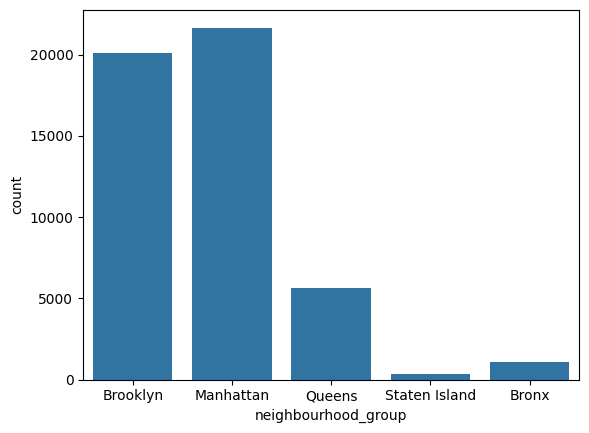

In [ ]:
sns.countplot(data=data, x='neighbourhood_group')

In [ ]:
data['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

<Axes: xlabel='room_type', ylabel='count'>

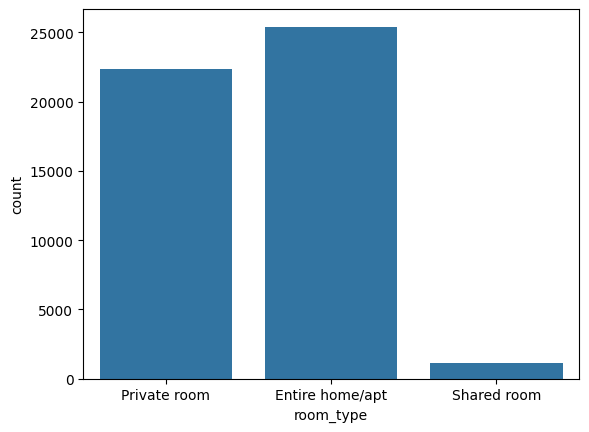

In [ ]:
sns.countplot(data=data, x='room_type')

In [ ]:
data['neighbourhood'] = data['neighbourhood'].str.lower().str.strip()

In [ ]:
data.isna().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,10052
calculated_host_listings_count,0


In [ ]:
data.isnull().mean() * 100

,0
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000
minimum_nights,0.000000
number_of_reviews,0.000000
reviews_per_month,20.558339
calculated_host_listings_count,0.000000


<Axes: >

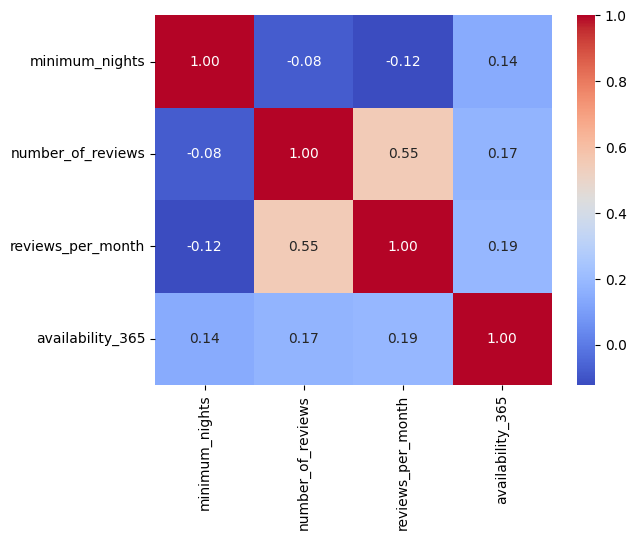

In [ ]:
sns.heatmap(
    data[
        [
            'minimum_nights',
            'number_of_reviews',
            'reviews_per_month',
            'availability_365',
        ]
    ].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
)

In [ ]:
data['reviews_per_month'] = data['reviews_per_month'].replace(np.nan, 0)

In [ ]:
data.isna().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


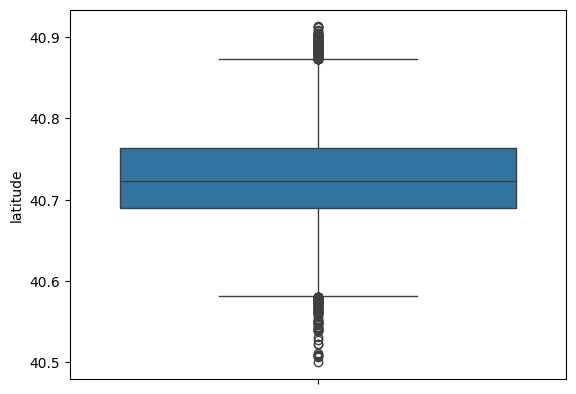

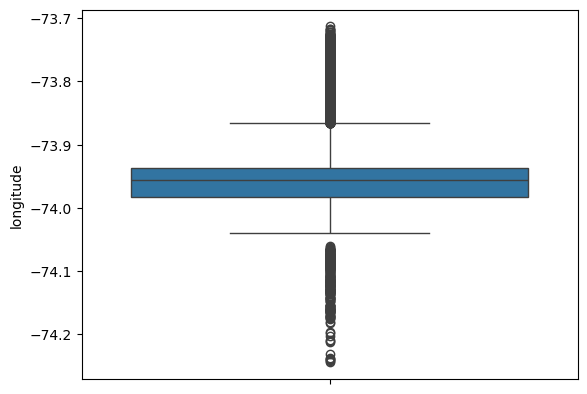

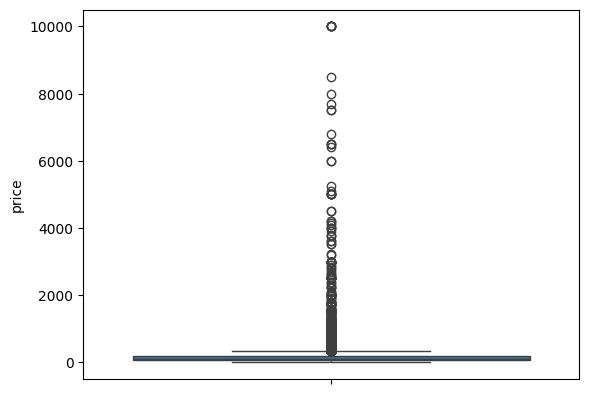

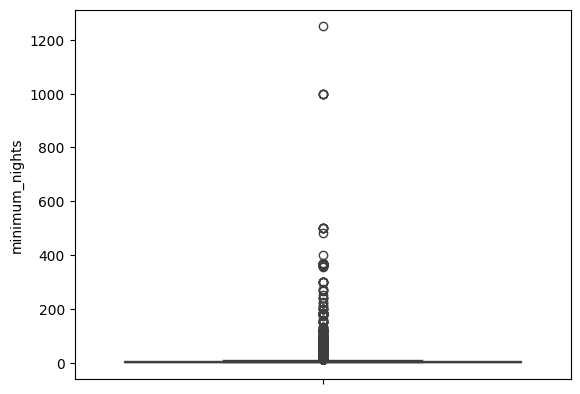

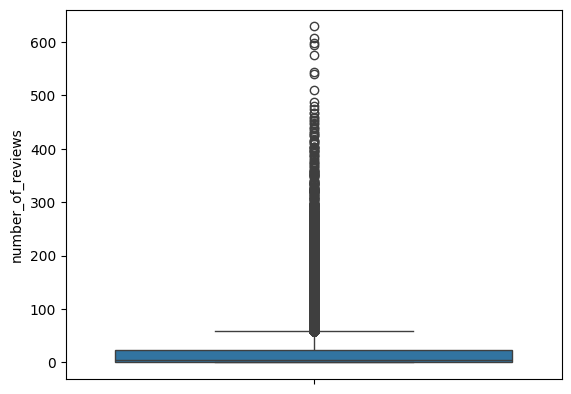

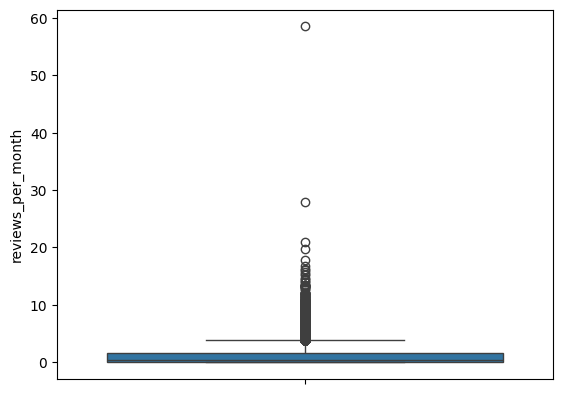

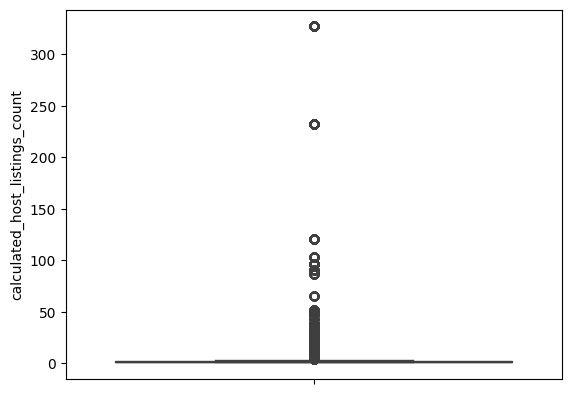

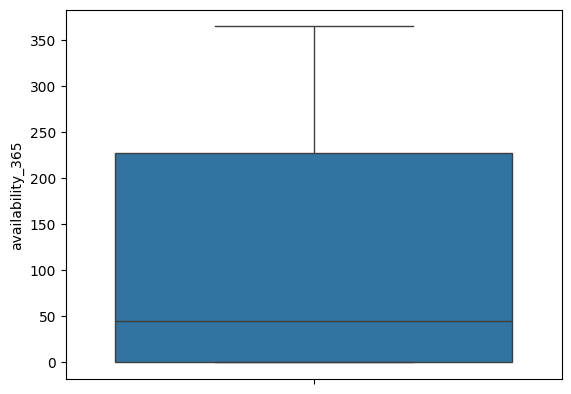

In [ ]:
for col in data.select_dtypes(include='number').columns:
    sns.boxplot(data[col])
    plt.show()

In [ ]:
data = data[
    (data['minimum_nights'] < 350) &
    (data['number_of_reviews'] < 500) &
    (data['reviews_per_month'] < 25) &
    (data['calculated_host_listings_count'] < 60)&
    (data['price'] < 900)
]

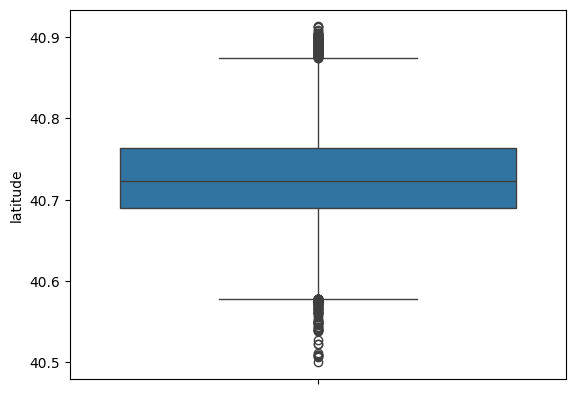

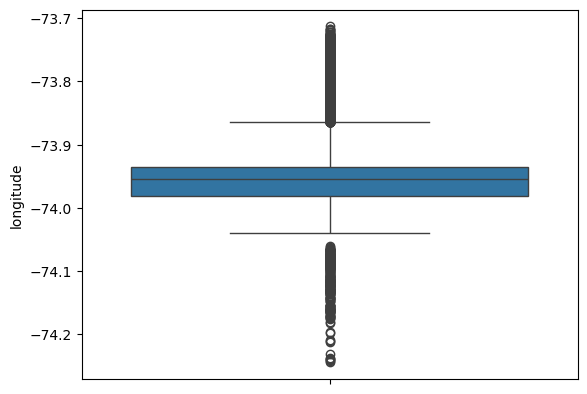

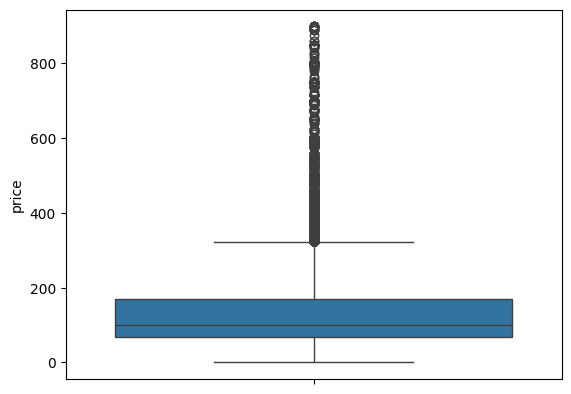

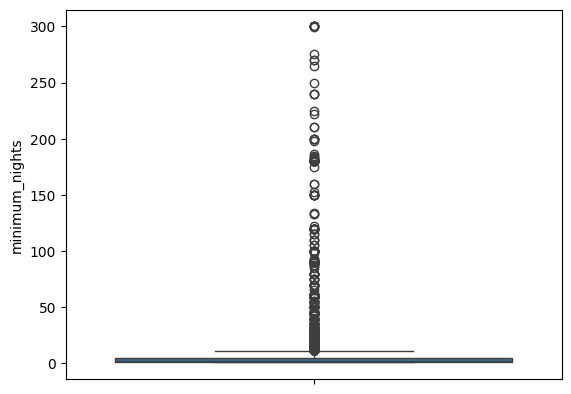

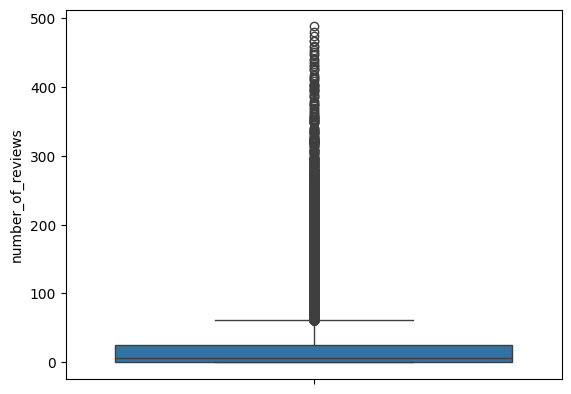

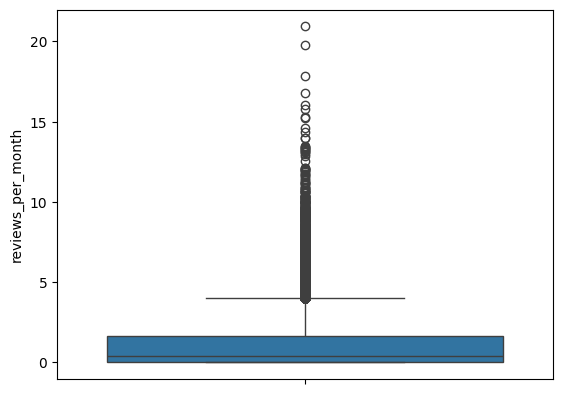

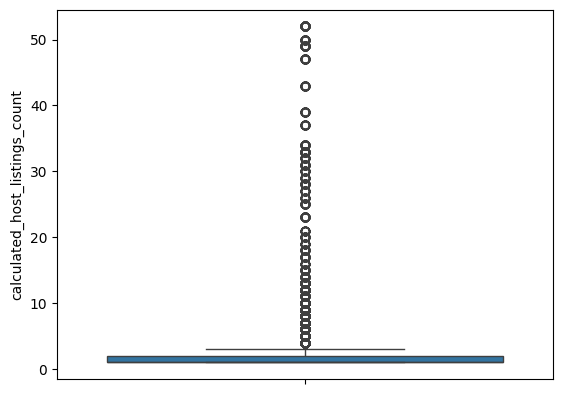

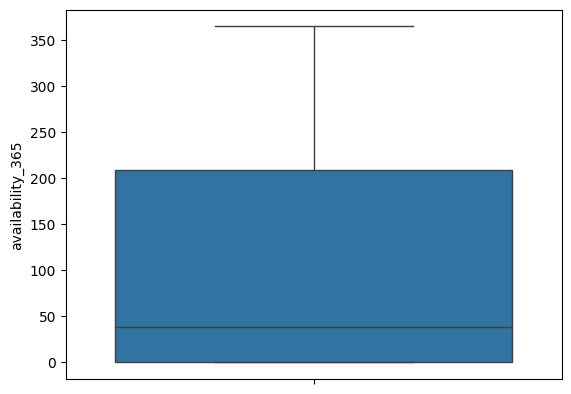

In [ ]:
for col in data.select_dtypes(include='number').columns:
    sns.boxplot(data[col])
    plt.show()

In [ ]:
data['price_category'] = pd.qcut(data['price'], q=3, labels=['Low', 'Medium', 'High'])

In [ ]:
data['price_category'] = data['price_category'].astype(object)

In [ ]:
data.drop('price', axis=1, inplace=True)

In [ ]:
data.shape

(47249, 11)

<Axes: xlabel='longitude', ylabel='latitude'>

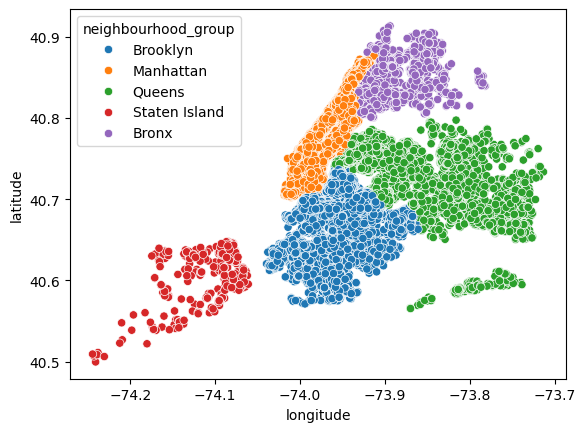

In [ ]:
sns.scatterplot(
    data=data, x='longitude', y='latitude', hue='neighbourhood_group'
)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [ ]:
X = data.drop('price_category', axis=1)
y = data['price_category']

print("Target distribution:")
print(y.value_counts())
print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)


Target distribution:
price_category
Low       16980
High      15593
Medium    14676
Name: count, dtype: int64

Target percentage:
price_category
Low       35.937269
High      33.001757
Medium    31.060975
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (37799, 10)
X_test: (9450, 10)
y_train: (37799,)
y_test: (9450,)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    'neighbourhood_group',

    'room_type'

]

numerical_features = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (37799, 15)
Processed X_test shape: (9450, 15)


In [ ]:
print("NaN in X_train:", np.isnan(X_train_processed).sum())
print("NaN in X_test:", np.isnan(X_test_processed).sum())
print("Inf in X_train:", np.isinf(X_train_processed).sum())
print("Inf in X_test:", np.isinf(X_test_processed).sum())

NaN in X_train: 0
NaN in X_test: 0
Inf in X_train: 0
Inf in X_test: 0


In [ ]:

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=preprocessor.get_feature_names_out()
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=preprocessor.get_feature_names_out()
)

print(X_train_processed.shape)
print(X_test_processed.shape)
print(y_train.shape)
print(y_test.shape)

(37799, 15)
(9450, 15)
(37799,)
(9450,)


In [ ]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(X_train_processed, y_train)


LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_train = model1.predict(X_train_processed)
train_accuracy = accuracy_score(y_train, y_pred_train)

y_pred_test = model1.predict(X_test_processed)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Logistic Regression train acc: {train_accuracy}")
print(f"Logistic Regression test acc: {test_accuracy}")

Logistic Regression train acc: 0.6587740416413133
Logistic Regression test acc: 0.6635978835978836


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(random_state=42)
model1.fit(X_train_processed, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_processed, y_train)

y_pred_train2 = model2.predict(X_train_processed)
y_pred_test2 = model2.predict(X_test_processed)

train_acc2 = accuracy_score(y_train, y_pred_train2)
test_acc2 = accuracy_score(y_test, y_pred_test2)

print(f"Decision Tree Train Acc: {train_acc2}")
print(f"Decision Tree Test Acc: {test_acc2}")

Decision Tree Train Acc: 0.999973544273658
Decision Tree Test Acc: 0.6042328042328042


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42)
model3.fit(X_train_processed, y_train)


RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_train3 = model3.predict(X_train_processed)
y_pred_test3 = model3.predict(X_test_processed)

train_acc3 = accuracy_score(y_train, y_pred_train3)
test_acc3 = accuracy_score(y_test, y_pred_test3)

print(f"Random Forest Train Acc: {train_acc3}")
print(f"Random Forest Test Acc: {test_acc3}")

Random Forest Train Acc: 0.7214212016190904
Random Forest Test Acc: 0.6947089947089947


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

model4 = AdaBoostClassifier(n_estimators=100, random_state=42)
model4.fit(X_train_processed, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_train4 = model4.predict(X_train_processed)
y_pred_test4 = model4.predict(X_test_processed)

train_acc4 = accuracy_score(y_train, y_pred_train4)
test_acc4 = accuracy_score(y_test, y_pred_test4)

print(f"AdaBoost Train Acc: {train_acc4}")
print(f"AdaBoost Test Acc: {test_acc4}")

AdaBoost Train Acc: 0.6735892483928146
AdaBoost Test Acc: 0.6747089947089947


In [ ]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, model1.predict(X_test_processed)))

print("\n=== Decision Tree ===")
print(classification_report(y_test, model2.predict(X_test_processed)))

print("\n=== Random Forest ===")
print(classification_report(y_test, model3.predict(X_test_processed)))

print("\n=== AdaBoost ===")
print(classification_report(y_test, model4.predict(X_test_processed)))

=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.66      0.76      0.71      3119
         Low       0.73      0.85      0.79      3396
      Medium       0.52      0.35      0.42      2935

    accuracy                           0.66      9450
   macro avg       0.64      0.65      0.64      9450
weighted avg       0.65      0.66      0.65      9450


=== Decision Tree ===
              precision    recall  f1-score   support

        High       0.64      0.63      0.64      3119
         Low       0.72      0.71      0.71      3396
      Medium       0.44      0.45      0.45      2935

    accuracy                           0.60      9450
   macro avg       0.60      0.60      0.60      9450
weighted avg       0.61      0.60      0.61      9450


=== Random Forest ===
              precision    recall  f1-score   support

        High       0.72      0.76      0.74      3119
         Low       0.76      0.85      0.80      3396
 

In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    'Logistic Regression': model1,
    'Decision Tree': model2,
    'Random Forest': model3,
    'AdaBoost': model4
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=10)
    print(f'{name} cv score is {np.mean(scores)} and std is {np.std(scores)}')

Logistic Regression cv score is 0.6582183635266461 and std is 0.004909138151519693
Decision Tree cv score is 0.6064710086792648 and std is 0.005156607123733976
Random Forest cv score is 0.6974522808447127 and std is 0.007504632331133229
AdaBoost cv score is 0.6725310648795698 and std is 0.004996615223978805


In [ ]:
data.shape

(47249, 11)

In [ ]:
import pickle
pickle.dump(model3, open('airbnb_model.pkl', 'wb'))

pickle.dump(preprocessor, open('airbnb_preprocessor.pkl', 'wb'))

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [ ]:
from google.colab import files

files.download('/content/airbnb_model.pkl')
files.download('/content/airbnb_preprocessor.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
import sys
print(sys.version)

3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
